# **Table of Contents**
* [**Table of Contents**](#**table-of-contents**)
  * [Imports](#imports)
  * [Clean Path](#clean-path)
  * [Clean Function](#clean-function)
* [1. CLEAN STANDARD ACS DATASETS](#1.-clean-standard-acs-datasets)
* [2. CLEAN POVERTY DATA](#2.-clean-poverty-data)
* [3. CLEAN INCOME DATA](#3.-clean-income-data)
* [4. CLEAN ACTIVE PERMITS](#4.-clean-active-permits)
* [5. GEOPANDAS - NEIGHBORHOODS](#5.-geopandas---neighborhoods)
    * [GeoDataFrame - Permits](#geodataframe---permits)
    * [GeoDataFrame - Tract Permits](#geodataframe---tract-permits)
* [6. MERGE PREP](#6.-merge-prep)
* [7. MERGING AND POLISHING](#7.-merging-and-polishing)
* [NEED INDEX](#need-index)
* [PLOTS](#plots)
* [TOC Generator](#toc-generator)

## Imports

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
#from sklearn.preprocessing import MinMaxScaler

## Clean Path

In [2]:
BASE_DIR = Path.cwd()

RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Clean Function

In [3]:
def clean_standard_acs_data(
    file_name: str, 
    output_name: str, 
    value_col_name: str,
    raw_dir: Path,
    processed_dir: Path,
    numeric_cols: list = None
) -> pd.DataFrame:
    """
    Cleans and standardizes American Community Survey (ACS) datasets.
    
    Reads a raw ACS CSV file, removes margin-of-error columns, transposes 
    the dataset, standardizes header names, extracts numeric Census Tract 
    identifiers, converts optional list of columns to numeric, and exports 
    the cleaned data to the processed directory.

    Args:
        file_name (str): The filename of the raw CSV to read.
        output_name (str): The desired filename for the cleaned CSV output.
        value_col_name (str): The standardized name to assign to the target 
            data column (e.g., 'MEDIAN_GROSS_RENT' or 'TOTAL').
        raw_dir (Path): The directory path containing the raw data files.
        processed_dir (Path): The directory path where cleaned data is saved.

    Returns:
        pd.DataFrame: The cleaned dataset as a pandas DataFrame.
    """
    input_path = raw_dir / file_name
    output_path = processed_dir / output_name

    df = pd.read_csv(input_path)

    # Drop Margin of Error columns
    error_columns = df.columns[df.columns.str.contains('Margin of Error', na=False)]
    df = df.drop(columns=error_columns)

    # Transpose and reset structure
    df = df.transpose().reset_index()
    df = df.rename(columns=df.iloc[0]).drop(df.index[0])

    # Clean column names
    df.columns = df.columns.str.strip()
    
    # Standardize important columns
    target_renames = {
        'Total:': 'TOTAL',
        'Median gross rent': value_col_name,
        'Median value': value_col_name,
        'Median value (dollars)': value_col_name,
        df.columns[0]: 'TRACT'
    }
    df = df.rename(columns=target_renames)

    # Extract tract number
    df['TRACT'] = df['TRACT'].str.extract(r'Census Tract ([\d.]+)')

    # Convert selected columns to numeric
    if numeric_cols:
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(
                    df[col].astype(str).str.replace(",", "", regex=False),
                    errors="coerce"
                )

    df.to_csv(output_path, index=True)
    print(f"Successfully processed and saved {output_name}")

    return df

# 1. CLEAN STANDARD ACS DATASETS

In [4]:
print("Processing standard ACS datasets...")

# Housing Age - Use 1980 and before as older units
pre_1980_cols = [
    "Built 1970 to 1979",
    "Built 1960 to 1969",
    "Built 1950 to 1959",
    "Built 1940 to 1949",
    "Built 1939 or earlier"
]

df_housing_age = clean_standard_acs_data(
    file_name='acs_2024_jefferson_housing_age_by_tract_b25034.csv',
    output_name='housing_age_clean.csv',
    value_col_name='TOTAL',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=["TOTAL"] + pre_1980_cols
)

df_rent = clean_standard_acs_data(
    file_name='acs_2024_jefferson_median_gross_rent_by_tract_b25064.csv',
    output_name='rent_clean.csv',
    value_col_name='GROSS_RENT_USD',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=['GROSS_RENT_USD']
)

df_home_value = clean_standard_acs_data(
    file_name='acs_2024_jefferson_median_home_value_by_tract_b25077.csv',
    output_name='home_value_clean.csv',
    value_col_name='HOME_VALUE_USD',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=['HOME_VALUE_USD']
)

df_rent_burden = clean_standard_acs_data(
    file_name='acs_2024_jefferson_rent_burden_by_tract_b25070.csv',
    output_name='rent_burden_clean.csv',
    value_col_name='TOTAL',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=['TOTAL', '50.0 percent or more']
)

Processing standard ACS datasets...
Successfully processed and saved housing_age_clean.csv
Successfully processed and saved rent_clean.csv
Successfully processed and saved home_value_clean.csv
Successfully processed and saved rent_burden_clean.csv


# 2. CLEAN POVERTY DATA

In [5]:
print("Processing Poverty dataset...")
df_poverty = pd.read_csv(
    RAW_DIR / 'acs_2024_jefferson_poverty_by_tract_s1701.csv')
df_poverty = df_poverty[["GEO_ID", "NAME",
                         "S1701_C01_001E", "S1701_C02_001E", "S1701_C03_001E"]]
df_poverty = df_poverty.drop(index=0)

df_poverty = df_poverty.rename(columns={
    "GEO_ID": "GEOID",
    "NAME": "TRACT",
    "S1701_C01_001E": "POPULATION",
    "S1701_C02_001E": "BELOW_POVERTY",
    "S1701_C03_001E": "POVERTY_RATE_PCT"
})
# Strip first 11 digits
df_poverty["GEOID"] = df_poverty["GEOID"].str[-11:]

df_poverty['TRACT'] = df_poverty['TRACT'].str.extract(r'Census Tract ([\d.]+)')

# Convert to numeric and remove commas to standardize
df_poverty["POVERTY_RATE_PCT"] = pd.to_numeric(
    df_poverty["POVERTY_RATE_PCT"].astype(str).str.replace(",", "", regex=False), 
    errors="coerce"
)

df_poverty.to_csv(PROCESSED_DIR / 'poverty_rate_clean.csv', index=False)
print("Successfully processed and saved poverty_rate_clean.csv")

Processing Poverty dataset...
Successfully processed and saved poverty_rate_clean.csv


# 3. CLEAN INCOME DATA

In [6]:
print("Processing Income dataset...")
df_income = pd.read_csv(
    RAW_DIR / 'acs_2024_jefferson_household_income_by_tract_b19013.csv')
df_income = df_income.rename(columns={
    "Label (Grouping)": "TRACT",
    "Median household income in the past 12 months (in 2024 inflation-adjusted dollars)": "HOUSEHOLD_INCOME_USD"
})

# Shift values up one to put on same row as TRACT
df_income['HOUSEHOLD_INCOME_USD'] = df_income['HOUSEHOLD_INCOME_USD'].shift(-1)
df_income = df_income.drop(df_income[df_income['TRACT'].str.contains(
    'Estimate|Margin of Error', na=False)].index)
df_income['TRACT'] = df_income['TRACT'].str.extract(r'Census Tract ([\d.]+)')

# Convert to numeric and remove commas to standardize
df_income["HOUSEHOLD_INCOME_USD"] = pd.to_numeric(
    df_income["HOUSEHOLD_INCOME_USD"].astype(str).str.replace(",", "", regex=False), 
    errors="coerce"
)

df_income.to_csv(PROCESSED_DIR / 'income_clean.csv', index=False)
print("Successfully processed and saved income_clean.csv")

Processing Income dataset...
Successfully processed and saved income_clean.csv


# 4. CLEAN ACTIVE PERMITS

In [7]:
print("Processing Active Permits dataset...")
df_permits = pd.read_csv(
    RAW_DIR / 'louisville_active_construction_permits.csv')

df_permits["ZIPCODE"] = df_permits["ZIPCODE"].astype(str).str.split("-").str[0]
df_permits = df_permits[['ISSUE_DATE', 'ADDRESS', 'CITY',
                         'ZIPCODE', 'LATITUDE', 'LONGITUDE', 'DISTRICT', 'NEIGHBORHOOD']]

# Convert to datetime and filter for 2024 efficiently
df_permits['ISSUE_DATE'] = pd.to_datetime(
    df_permits['ISSUE_DATE'], errors='coerce')
df_permits = df_permits[df_permits['ISSUE_DATE'].dt.year == 2024]

df_permits.to_csv(PROCESSED_DIR / 'permits_clean.csv', index=False)
print("Successfully processed and saved permits_2024_clean.csv")
print("All files processed successfully!")

Processing Active Permits dataset...
Successfully processed and saved permits_2024_clean.csv
All files processed successfully!


# 5. GEOPANDAS - NEIGHBORHOODS

In [8]:
# Using geopandas to establish neighborhood boundaries
neighborhoods = gpd.read_file( RAW_DIR / 'louisville_neighborhoods.shp')

# Convert to latitude and logitude - 4326 is commonly used for GPS-like mapping using degrees
neighborhoods = neighborhoods.to_crs("EPSG:4326")

### GeoDataFrame - Permits

In [9]:
# Convert to a GeoDataFrame
gdf_permits = gpd.GeoDataFrame(df_permits, geometry = gpd.points_from_xy(df_permits["LONGITUDE"], df_permits["LATITUDE"]), crs = "EPSG:4326")

# Spatial join to fill in missing Neighborhood data
# To note, this will only will in ~33% of the missing data, since ~66% of 2024 permits happened outside the defined neighborhood boundaries from the shapefile.
result_perm_neig = gpd.sjoin(gdf_permits, neighborhoods, how="left", predicate="intersects")

# Fill in the missing values
result_perm_neig["NEIGHBORHOOD"] = result_perm_neig["NEIGHBORHOOD"].fillna(result_perm_neig["NH_NAME"])

# Output clean file
result_perm_neig.to_csv(PROCESSED_DIR / "permits_neighborhoods_clean.csv", index = True)

### GeoDataFrame - Tract Permits

In [10]:
# Load shapefile
permits_tract = gpd.read_file(RAW_DIR / "tl_2023_21_tract.shp")

# Filter to Jefferson County (FIPS = 111)
permits_tract = permits_tract[permits_tract["COUNTYFP"] == "111"]

# Convert to ESPG:4326
permits_tract = permits_tract.to_crs("EPSG:4326")

In [11]:
# Join with our GeoDataFrame
result_perm_trac = gpd.sjoin(gdf_permits, permits_tract, how = "left", predicate = "intersects")

# 6. MERGE PREP

In [12]:
# Permits - Pull out GEOID and add a count column for plotting
permits_tract_count = (result_perm_trac.groupby("GEOID").size().reset_index(name = "PERMIT_COUNT"))

#----------------------------------------------------------------------------------------------------#

# Housing age - Add older unit column that sums the pre-1980 builds
df_housing_age["OLDER_UNITS"] = df_housing_age[pre_1980_cols].sum(axis=1)

# Calculate percentage
df_housing_age["OLDER_HOUSING_PCT"] = (
    df_housing_age["OLDER_UNITS"] / df_housing_age["TOTAL"]
) * 100

#----------------------------------------------------------------------------------------------------#

# Rent burden
df_rent_burden["RENT_BURDEN_PCT"] = (df_rent_burden["50.0 percent or more"] / df_rent_burden["TOTAL"]) * 100

# 7. MERGING AND POLISHING

In [13]:
print("Merging all DataFrames...")

merged = pd.merge(permits_tract_count, df_poverty[["GEOID", "TRACT", "POVERTY_RATE_PCT"]], on = "GEOID", how = "left")
merged = pd.merge(merged, df_housing_age[["TRACT", "OLDER_HOUSING_PCT"]], on = "TRACT", how = "left")
merged = pd.merge(merged, df_rent_burden[["TRACT", "RENT_BURDEN_PCT"]], on = "TRACT", how ="left")
merged = pd.merge(merged, df_home_value[["TRACT", "HOME_VALUE_USD"]], on = "TRACT", how = "left")
merged = pd.merge(merged, df_income[["TRACT", "HOUSEHOLD_INCOME_USD"]], on = "TRACT", how = "left")
merged = pd.merge(merged, df_rent[["TRACT", "GROSS_RENT_USD"]], on = "TRACT", how = "left")

# Order the columns a bit more logically
merged = merged[["GEOID", "TRACT", "HOUSEHOLD_INCOME_USD", "HOME_VALUE_USD", "GROSS_RENT_USD", "POVERTY_RATE_PCT", 
                 "RENT_BURDEN_PCT", "OLDER_HOUSING_PCT", "PERMIT_COUNT"]]

# Replace zeros with NaN
merged = merged.replace(0, np.nan)

# Replace blank strings and strings that are just spaces with NaN (just in case)
merged.replace(r'^\s*$', np.nan, regex=True, inplace=True)

merged.to_csv(PROCESSED_DIR / 'merged.csv', index=False)
print("Successfully merged and saved merged.csv.")
print("File processed successfully!")

Merging all DataFrames...
Successfully merged and saved merged.csv.
File processed successfully!


# NEED INDEX

In [14]:
df_plot = merged.copy()

need_cols = [
    "HOUSEHOLD_INCOME_USD",
    "HOME_VALUE_USD",
    "GROSS_RENT_USD",
    "POVERTY_RATE_PCT",
    "RENT_BURDEN_PCT",
    "OLDER_HOUSING_PCT"
]

# Min-max scaling
for col in need_cols:
    df_plot[col + "_scaled"] = (
        (df_plot[col] - df_plot[col].min()) /
        (df_plot[col].max() - df_plot[col].min())
    )

# Reverse columns where lower values indicate more need
reverse_cols = [
    "HOUSEHOLD_INCOME_USD",
    "HOME_VALUE_USD"
]

for col in reverse_cols:
    df_plot[col + "_scaled"] = 1 - df_plot[col + "_scaled"]

# Build need index
scaled_cols = [col + "_scaled" for col in need_cols]

df_plot["NEED_INDEX"] = df_plot[scaled_cols].mean(axis=1)

df_plot[["TRACT", "NEED_INDEX"]].head()

,TRACT,NEED_INDEX
0,2.01,0.629576
1,2.02,0.751900
2,3,0.603167
3,4,0.580819
4,6,0.536560


# PLOTS

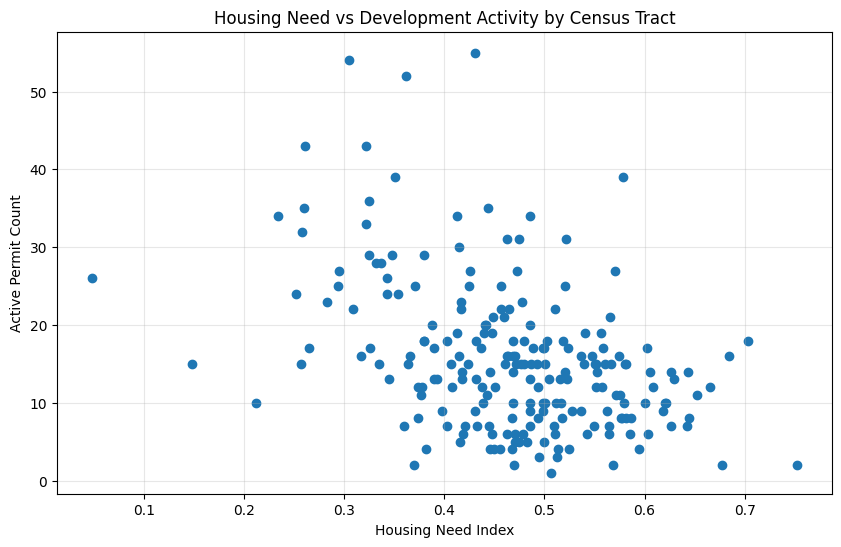

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["NEED_INDEX"], df_plot["PERMIT_COUNT"])
plt.xlabel("Housing Need Index")
plt.ylabel("Active Permit Count")
plt.title("Housing Need vs Development Activity by Census Tract")
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Top 10 highest need tracts

df_plot.sort_values("NEED_INDEX", ascending=False)[
    ["TRACT", "NEED_INDEX", "PERMIT_COUNT"]
].head(10)

,TRACT,NEED_INDEX,PERMIT_COUNT
1,2.02,0.751900,2
198,124.13,0.703153,18
15,18,0.684115,16
24,35.02,0.676882,2
17,23,0.665252,12
7,9,0.652222,11
6,8,0.644095,8
21,28,0.643138,14
41,56,0.642739,7
0,2.01,0.629576,13


# TOC Generator 

Do not delete code. It will read your markdown and generate a TOC we can put in the notebook for easy navigation. 

In [17]:
import json
import os


def generate_toc_from_notebook(notebook_path):
    """
    Parses a local .ipynb file and generates Markdown for a Table of Contents.
    """
    if not os.path.isfile(notebook_path):
        print(f"❌ Error: File not found at '{notebook_path}'")
        return

    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook = json.load(f)

    toc_markdown = "# **Table of Contents**\n"
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') == 'markdown':
            for line in cell.get('source', []):
                if line.strip().startswith('#'):
                    level = line.count('#')
                    title = line.strip('#').strip()
                    link = title.lower().replace(' ', '-').strip('-.()')
                    indent = '  ' * (level - 1)
                    toc_markdown += f"{indent}* [{title}](#{link})\n"

    print("\n--- ✅ Copy the Markdown below and paste"
          "it into a new markdown cell ---\n")
    print(toc_markdown)


if __name__ == "__main__":
    # Example usage
    notebook_path = 'curtis.ipynb'  # Replace with your notebook path
    generate_toc_from_notebook(notebook_path)


--- ✅ Copy the Markdown below and pasteit into a new markdown cell ---

# **Table of Contents**
* [**Table of Contents**](#**table-of-contents**)
  * [Imports](#imports)
  * [Clean Path](#clean-path)
  * [Clean Function](#clean-function)
* [1. CLEAN STANDARD ACS DATASETS](#1.-clean-standard-acs-datasets)
* [2. CLEAN POVERTY DATA](#2.-clean-poverty-data)
* [3. CLEAN INCOME DATA](#3.-clean-income-data)
* [4. CLEAN ACTIVE PERMITS](#4.-clean-active-permits)
* [5. GEOPANDAS - NEIGHBORHOODS](#5.-geopandas---neighborhoods)
    * [GeoDataFrame - Permits](#geodataframe---permits)
    * [GeoDataFrame - Tract Permits](#geodataframe---tract-permits)
* [6. MERGE PREP](#6.-merge-prep)
* [7. MERGING AND POLISHING](#7.-merging-and-polishing)
* [NEED INDEX](#need-index)
* [PLOTS](#plots)
* [TOC Generator](#toc-generator)

